<a href="https://colab.research.google.com/github/arman-hossain45/Deep_learning_Neural_network/blob/main/auto_grad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Hellow world")

Hellow world


# Without auto_Grad manuall process

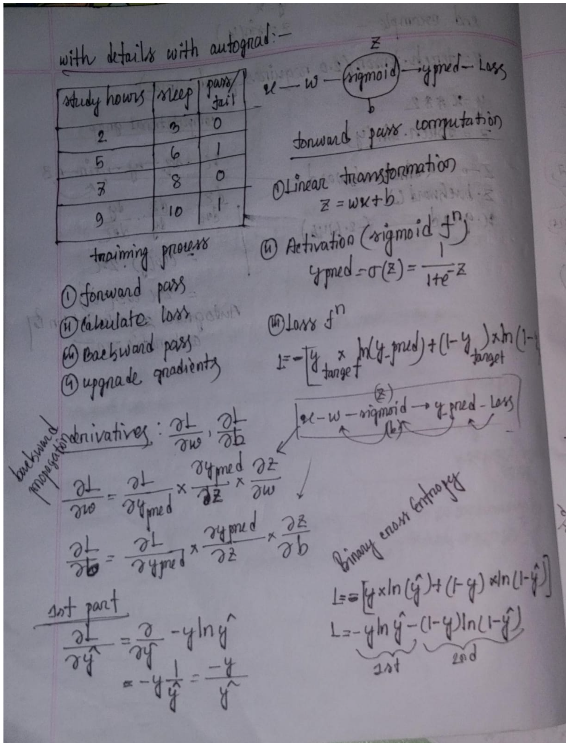

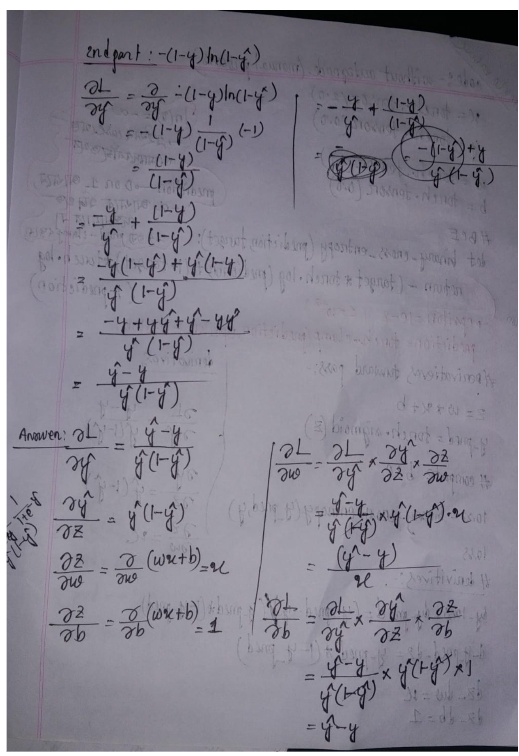

In [2]:
import torch

In [3]:
x = torch.tensor(2.0)

In [4]:
y = torch.tensor(0.0)

In [5]:
w = torch.tensor(1.0)
b = torch.tensor (0.0)

In [6]:
# BCE

def bce(prediction,target):
  epsilon=1e-8
  prediction = torch.clamp(prediction,epsilon,1-epsilon)
  return -(target*torch.log(prediction)+(1-target)*torch.log(1-prediction))

# derivatives forward pass

In [7]:
z= w*x+b
y_pred= torch.sigmoid(z)

#compute bce

loss= bce(y_pred,y)
loss

tensor(2.1269)

In [8]:
dy_loss_dy_pred=(y_pred-y)/y_pred*(1-y_pred)
d_y_pred_dz= y_pred*(1-y_pred)
dz_dw= x
dz_db =1

# main part
dl_dw=dy_loss_dy_pred*d_y_pred_dz*dz_dw
dl_db = dy_loss_dy_pred*d_y_pred_dz*dz_db

In [9]:
dl_db

tensor(0.0125)

In [10]:
dl_dw

tensor(0.0250)

# now same things we can do it now using auto grade

In [12]:
x= torch.tensor(2.0)
y=torch.tensor(0.0)

w = torch.tensor(1.0, requires_grad =True)
b = torch.tensor(0.0, requires_grad =True)

z=w*x+b
z


tensor(2., grad_fn=<AddBackward0>)

In [13]:
y_pred = torch.sigmoid(z)
y_pred

tensor(0.8808, grad_fn=<SigmoidBackward0>)

In [14]:
loss = bce(y_pred,y)
loss

tensor(2.1269, grad_fn=<NegBackward0>)

In [16]:
loss.backward()

In [17]:
w.grad

tensor(1.7616)

In [18]:
b.grad

tensor(0.8808)

# using multdiple input

In [19]:
x = torch.tensor([1.0,2.0,3.0],requires_grad=True)
x

tensor([1., 2., 3.], requires_grad=True)

In [20]:
y= (x**2).mean()
y.backward()
x.grad

tensor([0.6667, 1.3333, 2.0000])

# Clearing grad

In [21]:
x=torch.tensor(2.0,requires_grad = True)
x

tensor(2., requires_grad=True)

In [34]:
y=x**2
y

tensor(4.)

In [31]:
y.backward()
x.grad

tensor(4.)

In [32]:
# option 1
x.grad.zero_()

tensor(0.)

In [35]:
# Option 2
x.requires_grad_(False)
y.backward()# here it show error for this code thats why we can use this line of code


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

# Detach

In [38]:
x = torch.tensor(2.0, requires_grad=True)
x
z = x.detach()
x

tensor(2., requires_grad=True)

In [40]:
z# here we can see that there no backward track

tensor(2.)

In [41]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [42]:
y1=z**2
y1

tensor(4.)

In [44]:
y.backward()

In [45]:
y1.backward()# its not work because we detach this from  the original variable

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn